In [4]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random
from tqdm.auto import tqdm
from scipy.spatial import ConvexHull,QhullError

In [5]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [[0,0.5*a,0.5*a],[0.5*a,0,0.5*a],[0.5*a,0.5*a,0],[0,0,0],\
                    [0,0,a],[0,a,0],[a,0,0],[a,a,0],\
                    [0,a,a],[a,0,a],[a,a,a],[a,0.5*a,0.5*a],\
                    [0.5*a,a,0.5*a],[0.5*a,0.5*a,a]]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
def extendfcc(lattice,a,x,y,z):
    lattice_extend = []
    for i in range(0,x):
        for j in range(0,y):
            for k in range(0,z):
                for o in range(0,len(lattice)):
                    if not lattice_extend.__contains__([lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]):
                        lattice_extend.extend([[lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]])
    return np.array(lattice_extend)

In [3]:
#gauss
#making lattice

def empty_lattice(lc,n1,n2,n3):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    mid_position=np.mean(lattice,axis=0)
    # lattice=np.round(lattice-mid_position,6)
    closest_index=np.where(np.all(np.isclose(mid_position,lattice,rtol=lc/(2*np.sqrt(2))),axis=1))[0][0]
    lattice=lattice-lattice[closest_index]
    return order_pos(lattice)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

def particles_encode_gen_no_oblate(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice_big[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n_max,n_max,n_max,num_atoms)
# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # print(f"length={np.mean(lattice_big,axis=0)}")
    times=random.randint(1,3)

    #this is too strong
    while num_points<num_atoms*2:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
    # print(f"length={np.mean(lattice,axis=0)}")
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def particles_encode_gen_lattice(lc,n1,n2,n3,num_atoms=None,max_num_atoms=None):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    indices=[]
    lattice=empty_lattice(lc,n1,n2,n3,mean_position)
    num_points=len(lattice)
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice[i],lattice_big,rtol=1e-1),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-3),axis=1))[0])
    # print(len(particle),len(index))
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon
def convex_particle(genome,lc,max_num_atoms):
    indices=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    hull=ConvexHull(particle)
    # print(hull)
    for points in lattice_big:
        if is_point_in_hull(points,hull):
            indices.extend(np.where(np.all(np.isclose(points,particle,rtol=1e-3),axis=1))[0])
        
    genome_recon=np.zeros(len(lattice_big))
    for i in indices:
        genome_recon[indices[i]]=1
    return genome_recon
def is_point_in_hull(point,hull):
    equations=hull.equations
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0)

def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    #oblate set
    assert(len(set(parameters))==len(parameters))
    return generations,parameters

def fitness(genome,lc,max_num_atoms,descriptors:dict):
    genome=np.array(genome)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    #np.sum((true_dis-pred_dis)**2)
    sim=np.max(np.abs(pred_dis/true_dis-1))
    return sim,pred_dis

            
def parents(population,parameters,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            return list(population[i]),parameters[i]
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return (p-np.min(p))/(np.max(p)-np.min(p))

def crossover(lc,parent1,parent2,cross_over_rate=0.6,max_num_atoms=100):
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,lc,max_num_atoms)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,lc,max_num_atoms)
        parent1=parent1_up+parent2_down
        parent2=parent2_up+parent1_down
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        parent1[parent1>1]=1
        parent2[parent2>1]=1
        return parent1,parent2
    else:
        return parent1,parent2

def mutation(genome,lc,max_num_atoms,mutation_rate=0.3):
    mr=random.uniform(0,1)
    num_atoms=len(np.where(np.array(genome)==1)[0])
    if mr<=mutation_rate/3:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<1/3*num_atoms and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            genome_update=atom_trancate_center(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
    if mr>mutation_rate/3 and mr<=mutation_rate*2/3:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<1/3*num_atoms and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            genome_update=atom_trancate_arbi(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
    if mr>mutation_rate*2/3 and mr<=mutation_rate:
        #2. initialization of populations
        genome_update = ini_population(lc=lc,
                                    population_size=1,
                                    max_num_atoms=max_num_atoms,
                                    num_atoms=None)[0][0]
        
    else:
        genome_update=genome
    return genome_update
    
def atom_cut_up_down_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    closest_index=np.where(np.all(np.isclose(center,particle,rtol=lc/(1.8*np.sqrt(2))),axis=1))[0][0]
    particle_shift=particle-particle[closest_index]
    center=np.mean(particle_shift,axis=0)
    normal=normal_vector(center,theta,phi)
    
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle_shift:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=-lc/np.sqrt(2):
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=lc/np.sqrt(2):
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    genome_up_recon=encode_fromcoord(trancate_up_particle,lc,max_num_atoms)
    genome_down_recon=encode_fromcoord(trancate_down_particle,lc,max_num_atoms)
    return np.array(genome_up_recon),np.array(genome_down_recon)


def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        genome_recon=np.zeros(len(genome))
    else:
        genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    # print(len(particle),len(trancate_particle),len(np.where(np.array(genome_recon)==1)[0]))
    return genome_recon
    
def atom_trancate_arbi(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center_get=[]
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:
    center=random.choice(particle)
    # else:
    #     return particle
    ## points with coordination numbers are 12 are considered as the center of planes for truncation.
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<5:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    return genome_recon
def convex_particle(genome,lc,max_num_atoms):
    indices=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    try:
        hull=ConvexHull(particle)
    except QhullError:
        print("less than 3 dimensions")
        print(particle)
        return genome
    for points in lattice_big:
        if is_point_in_hull(points,hull,lc):
            indices.extend(np.where(np.all(np.isclose(points,lattice_big,rtol=1e-1),axis=1))[0])
    # print(len(indices))
    # print(len(particle))
    genome_recon=np.zeros(len(lattice_big))
    for i in indices:
        genome_recon[i]=1
    return genome_recon
def is_point_in_hull(point,hull,lc):
    equations=hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=lc/(2*np.sqrt(2)))

        

def genetic_algorithm(max_num_atoms=200,
                      generations=40,
                      population_size=100,
                      lc=3.77,
                      mutation_rate=0.3,
                      cross_over_rate=0.3,
                      descriptors={
                                    "flattening_moment": 1,
                                    "atom_number":55
                      }
                # "CN1":6,
                # "CN2":1.5,
                # "CN3":2,
                # "CN4":5

    ):
    #1. set up parameters

    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)

    #2. initialization of populations
    populations,parameters = ini_population(lc=lc,
                                population_size=population_size,
                                max_num_atoms=max_num_atoms,
                                num_atoms=None)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
       
        #check duplicates, if duplicates exist, then generate a new structure
        for _ in range(population_size//2):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1,parameters1=parents(populations,parameters,fitness_values)
            parent2,parameters2=parents(populations,parameters,fitness_values)
            fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            #[2]. crossover and mutation to generate offsprings
            children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
            children1=convex_particle(children1,lc,max_num_atoms)
            children2=convex_particle(children2,lc,max_num_atoms)
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
            #convex hull

            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1,children2])
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values=[]
        predict_values=[]
        for genome in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        best_fitness=min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        best_index=fitness_values.index(best_fitness)
        #[2]. reconstruct the best solution from codes using new_populations.
        particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(ave_fitness)                         #dong
        #[4]. print output
        print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
        #[5]. update populations
        populations=new_populations
        #[6]. early stopping
        # if generation>10:
        #     error=fitness_record[generation-1]-fitness_record[generation]
        #     if error<1e-4:
        #         break
    #4. record the best solution
    best_index=fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
        last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
        ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    return best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population
# def genome(num_atoms):
#     np.random

In [95]:
best_atoms=[]
fitness_records=[]
fitness_values=[]
best_particles=[]
last_atom_lists=[]
for i in range(1):
    # best_atom=None
    # fitness_record=None
    # fitness_value=None
    # best_particle=None
    # last_atom_list=None
    # ini_atom_list=None
    best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population=genetic_algorithm()
    # best_atoms.append(best_atom)
    # fitness_records.append(fitness_record)
    # fitness_values.append(fitness_value)
    # best_particles.append(best_particle)
    # last_atom_lists.append(last_atom_list)
# best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'flattening_moment': 1, 'atom_number': 55}


  0%|          | 0/40 [00:00<?, ?it/s]

Generation0:ave Finess=1.0486272727272727,best Predict=[ 0.96 54.  ]
Generation1:ave Finess=0.8159272727272727,best Predict=[ 0.98 53.  ]
Generation2:ave Finess=0.6589818181818181,best Predict=[ 0.98 53.  ]
Generation3:ave Finess=0.5069363636363636,best Predict=[ 0.98 53.  ]
Generation4:ave Finess=0.46518181818181825,best Predict=[ 1. 55.]
Generation5:ave Finess=0.4114090909090909,best Predict=[ 1. 55.]
Generation6:ave Finess=0.3004454545454545,best Predict=[ 1. 55.]
Generation7:ave Finess=0.46187272727272727,best Predict=[ 1. 55.]
Generation8:ave Finess=0.4275272727272727,best Predict=[ 1. 55.]
Generation9:ave Finess=0.4789545454545454,best Predict=[ 1. 55.]
Generation10:ave Finess=0.3491909090909091,best Predict=[ 1. 55.]
Generation11:ave Finess=0.4374363636363636,best Predict=[ 1. 55.]
Generation12:ave Finess=0.41923636363636363,best Predict=[ 1. 55.]
Generation13:ave Finess=0.4533818181818182,best Predict=[ 1. 55.]
Generation14:ave Finess=0.4810363636363636,best Predict=[ 1. 55.]
G

# initial


In [42]:
def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    #oblate set
    assert(len(set(parameters))==len(parameters))
    return generations,parameters

def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # print(f"length={np.mean(lattice_big,axis=0)}")

    #this is too strong
    while num_points<num_atoms*2:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
    # print(f"length={np.mean(lattice,axis=0)}")
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)


572
358


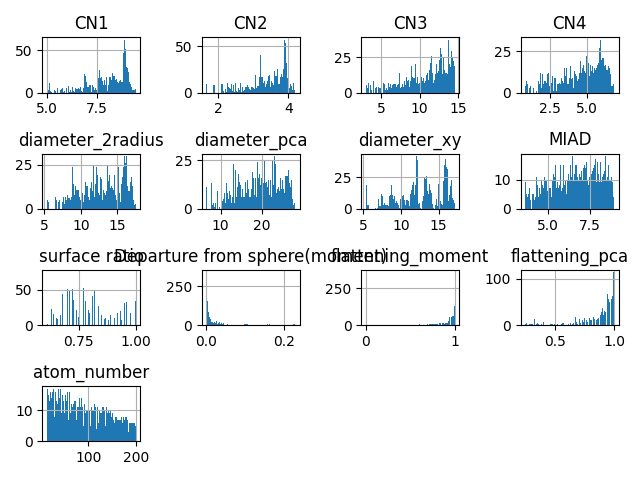

In [43]:
max_num_atoms=200
generations=30
population_size=1000
lc=3.77
mutation_rate=0.3
cross_over_rate=0.3
descriptors={
            "flattening_moment": 1,
            "atom_number":55
}
num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lattice_big=empty_lattice(lc,n_max,n_max,n_max)

#2. initialization of populations
populations,parameters = ini_population(lc=lc,
                            population_size=population_size,
                            max_num_atoms=max_num_atoms,
                            num_atoms=None)
particle_list=[]
for i in range(len(populations)):
    particle,_=recon_coordfromcodes(populations[i],lc,max_num_atoms)
    particle_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
particles_descriptors=[]
bas=[]

for i in range(len(particle_list)):
    particles_descriptors.append(descriptor_table(particle_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()
# best_clustering_energy=min(clustering_energy_values)
#[3]. record the reconstructed particles using Atoms objects.
print(len(np.where((pdes['flattening_moment']<1)&(pdes['flattening_moment']>0))[0]))
print(len(np.where(pdes['flattening_moment']==0)[0]))

In [51]:
pdes[pdes['flattening_moment']==0]

,CN1,CN2,CN3,CN4,diameter_2radius,diameter_pca,diameter_xy,MIAD,surface ratio,Departure from sphere(moment),flattening_moment,flattening_pca,atom_number
6,8.94,3.88,13.86,6.12,15.87,26.03,15.87,8.14,0.69,0.001124,0.0,0.98,153
10,7.76,3.44,10.59,4.59,11.31,18.56,11.31,6.30,0.79,0.000000,0.0,1.00,68
11,5.41,2.12,4.35,1.94,7.69,11.42,7.45,4.18,1.00,0.032616,0.0,0.99,17
14,8.87,3.84,13.45,5.99,15.90,24.49,15.62,7.96,0.72,0.007849,0.0,0.92,141
15,6.83,2.34,7.17,2.76,9.38,12.94,9.37,4.80,0.97,0.012111,0.0,0.91,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,9.12,3.93,14.39,6.58,16.69,27.19,16.69,8.58,0.68,0.000396,0.0,0.94,179
994,8.15,3.46,11.51,4.88,12.53,19.96,12.14,6.67,0.83,0.002217,0.0,1.00,82
995,8.32,3.55,12.13,5.17,13.63,20.50,12.95,6.98,0.77,0.005246,0.0,0.99,94
997,5.25,2.25,4.00,1.88,7.60,7.77,6.60,4.10,1.00,0.037975,0.0,1.00,16


In [55]:
view(particle_list[15])

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

In [8]:
%matplotlib widget

KeyboardInterrupt: 

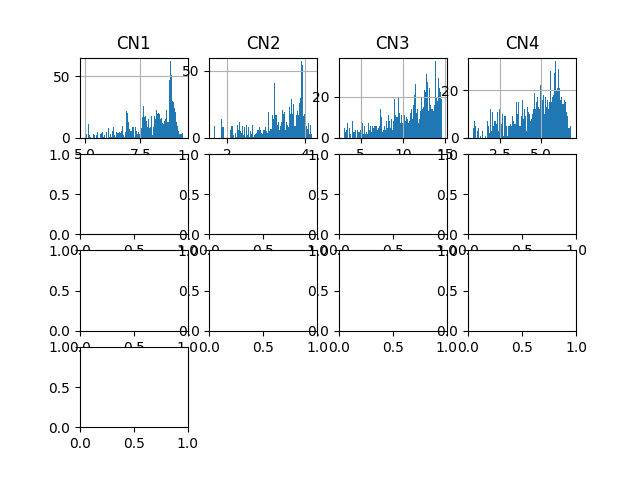

In [56]:
particles_descriptors=[]
bas=[]

for i in range(len(particle_list)):
    particles_descriptors.append(descriptor_table(particle_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

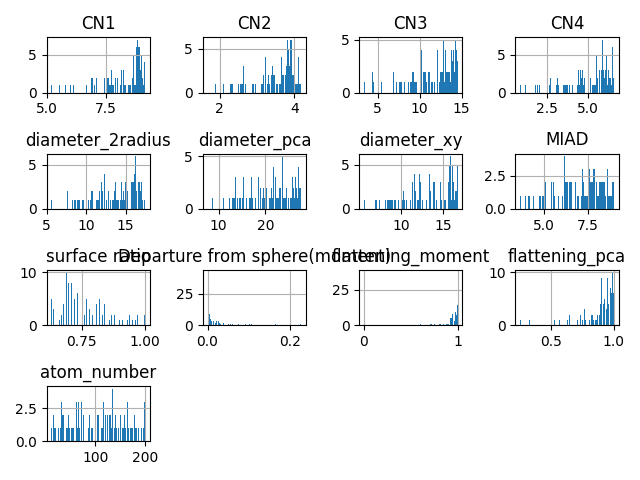

In [74]:
particles_descriptors=[]
bas=[]

for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [17]:
len(np.where(pdes["flattening_moment"]==0)[0])
pdes.shape[1]

13

""


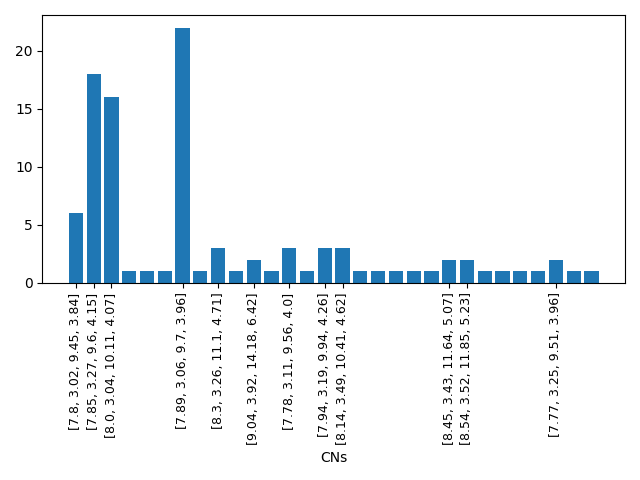

In [78]:
list_par=[]
for i in range(pdes.shape[0]):
    list_par.append([pdes.iloc[i]["CN1"],pdes.iloc[i]["CN2"],pdes.iloc[i]["CN3"],pdes.iloc[i]["CN4"]])

par_dict={}
list_read=[]
for i in range(pdes.shape[0]):
    indices=np.where(np.isclose(list_par[i],list_par,rtol=1e-2).all(axis=1))[0]
    # print(indices)
    
    # print(list_read)
    if i not in list_read:
        list_read.extend(indices)
        par_dict[f"{list_par[i]}"]={"indices":indices,"num":len(indices)}


par_dict=pd.DataFrame(par_dict)
# print(par_dict)
i=0
index_get=[]
values=[]
for k,v in par_dict.items():
    if v['num']!=1:
        values.append(k)
        index_get.append(i)
    i+=1

plt.figure()
plt.bar(np.arange(par_dict.shape[1]),par_dict.loc["num"])
plt.xlabel("CNs")
plt.xticks(index_get,values,rotation=90,fontsize=9)  
plt.tight_layout()

In [101]:
%matplotlib widget

Text(0, 0.5, 'Occurance')

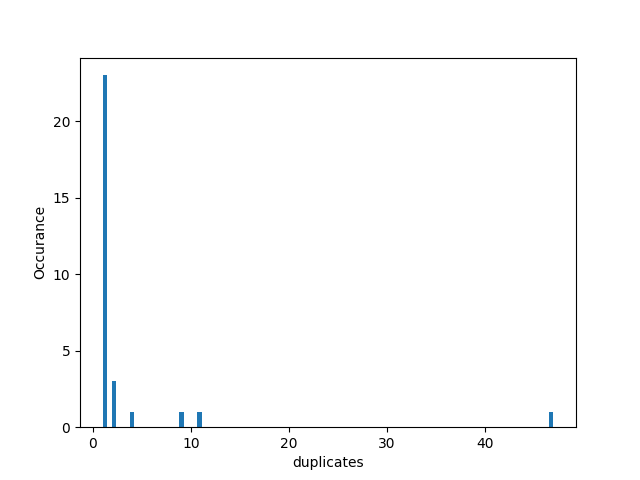

In [102]:
plt.figure()
plt.hist(par_dict.loc['num'],100)
plt.xlabel('duplicates')

plt.ylabel('Occurance')

In [88]:
par_dict

,"[8.23, 3.53, 11.72, 4.98]","[6.4, 2.32, 6.4, 2.56]","[8.65, 3.88, 12.59, 5.61]","[9.01, 4.08, 13.84, 6.26]","[8.16, 3.43, 11.27, 4.78]","[8.85, 3.91, 13.62, 5.87]","[7.17, 3.28, 8.28, 4.0]","[8.96, 3.95, 14.12, 6.16]","[8.29, 3.47, 12.13, 5.13]","[8.86, 3.69, 12.98, 5.85]",...,"[8.49, 3.88, 12.0, 5.37]","[7.19, 3.0, 8.81, 3.57]","[8.36, 3.8, 11.5, 5.14]","[8.34, 3.58, 12.13, 5.18]","[7.8, 3.42, 10.67, 4.58]","[9.18, 4.15, 14.2, 6.49]","[6.88, 2.76, 7.06, 2.76]","[7.86, 3.38, 10.82, 4.65]","[8.79, 3.66, 12.68, 5.64]","[8.36, 3.53, 12.23, 5.19]"
indices,"[0, 6]",[1],[2],"[3, 84]",[4],"[5, 99]","[7, 42]",[8],"[9, 77]",[10],...,[86],[87],[88],[89],[92],[93],[95],[96],"[74, 97]",[98]
num,2,1,1,2,1,2,2,1,2,1,...,1,1,1,1,1,1,1,1,2,1


NameError: name 'ar_dict' is not defined

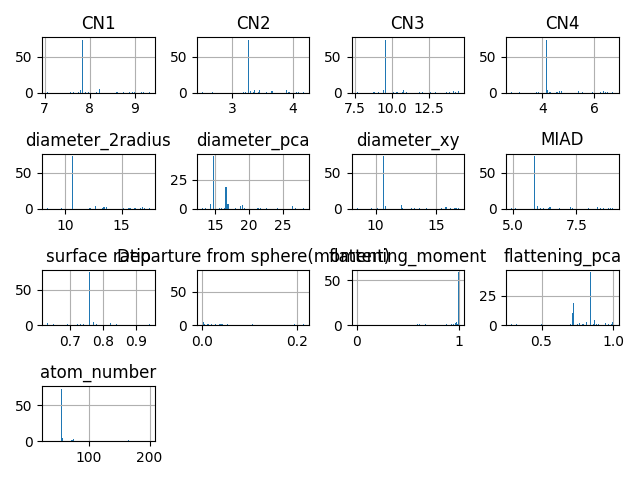

In [97]:
particles_descriptors=[]
bas=[]

for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

Text(0, 0.5, 'Occurance')

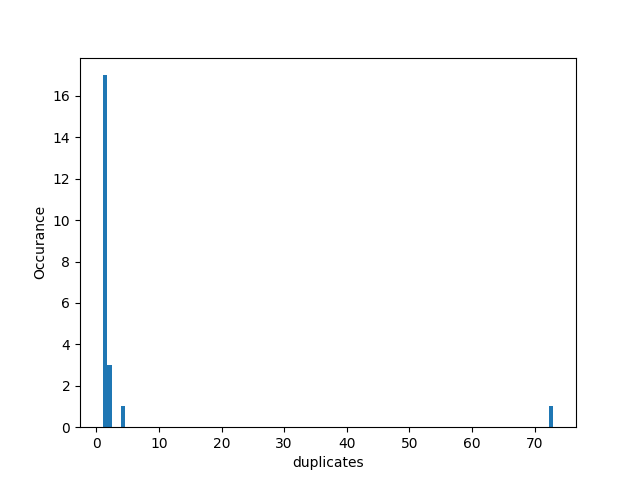

In [98]:
list_par=[]
for i in range(pdes.shape[0]):
    list_par.append([pdes.iloc[i]["CN1"],pdes.iloc[i]["CN2"],pdes.iloc[i]["CN3"],pdes.iloc[i]["CN4"]])

par_dict={}
list_read=[]
for i in range(pdes.shape[0]):
    indices=np.where(np.isclose(list_par[i],list_par,rtol=1e-2).all(axis=1))[0]
    # print(indices)
    
    # print(list_read)
    if i not in list_read:
        list_read.extend(indices)
        par_dict[f"{list_par[i]}"]={"indices":indices,"num":len(indices)}


par_dict=pd.DataFrame(par_dict)
# print(par_dict)
i=0
index_get=[]
values=[]
for k,v in par_dict.items():
    if v['num']!=1:
        values.append(k)
        index_get.append(i)
    i+=1
plt.figure()
plt.hist(par_dict.loc['num'],100)
plt.xlabel('duplicates')
plt.ylabel('Occurance')

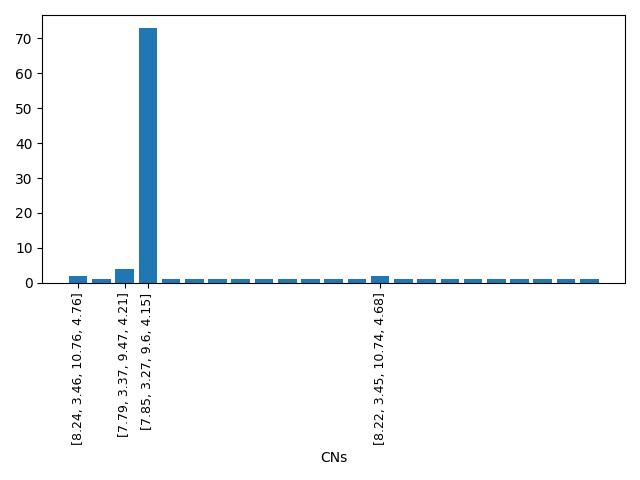

In [99]:
list_par=[]
for i in range(pdes.shape[0]):
    list_par.append([pdes.iloc[i]["CN1"],pdes.iloc[i]["CN2"],pdes.iloc[i]["CN3"],pdes.iloc[i]["CN4"]])

par_dict={}
list_read=[]
for i in range(pdes.shape[0]):
    indices=np.where(np.isclose(list_par[i],list_par,rtol=1e-3).all(axis=1))[0]
    # print(indices)
    
    # print(list_read)
    if i not in list_read:
        list_read.extend(indices)
        par_dict[f"{list_par[i]}"]={"indices":indices,"num":len(indices)}


par_dict=pd.DataFrame(par_dict)
# print(par_dict)
i=0
index_get=[]
values=[]
for k,v in par_dict.items():
    if v['num']!=1:
        values.append(k)
        index_get.append(i)
    i+=1

plt.figure()
plt.bar(np.arange(par_dict.shape[1]),par_dict.loc["num"])
plt.xlabel("CNs")
plt.xticks(index_get,values,rotation=90,fontsize=9)  
plt.tight_layout()

In [100]:
par_dict

,"[8.24, 3.46, 10.76, 4.76]","[7.9, 3.18, 10.16, 4.3]","[7.79, 3.37, 9.47, 4.21]","[7.85, 3.27, 9.6, 4.15]","[7.58, 2.68, 8.84, 3.16]","[9.33, 3.94, 14.51, 6.74]","[8.61, 3.58, 11.88, 5.37]","[8.59, 3.66, 12.08, 5.37]","[8.95, 3.89, 12.93, 6.01]","[7.64, 3.36, 8.73, 3.76]",...,"[8.22, 3.45, 10.74, 4.68]","[8.17, 3.44, 10.7, 4.56]","[9.02, 3.89, 14.11, 6.35]","[8.99, 4.07, 13.84, 6.23]","[7.06, 2.5, 7.62, 2.81]","[7.97, 3.31, 10.31, 4.31]","[9.15, 4.09, 14.47, 6.46]","[9.2, 4.19, 14.28, 6.52]","[8.22, 3.22, 10.97, 4.58]","[9.02, 3.92, 14.11, 6.35]"
indices,"[0, 86]",[1],"[2, 3, 55, 73]","[4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17...",[5],[18],[22],[23],[26],[41],...,"[53, 62]",[63],[64],[67],[83],[87],[90],[97],[98],[99]
num,2,1,4,73,1,1,1,1,1,1,...,2,1,1,1,1,1,1,1,1,1


In [102]:
pdes.iloc[4]

CN1                               7.85
CN2                               3.27
CN3                               9.60
CN4                               4.15
diameter_2radius                 10.66
diameter_pca                     14.79
diameter_xy                      10.66
MIAD                              5.82
surface ratio                     0.76
Departure from sphere(moment)     0.00
flattening_moment                 1.00
flattening_pca                    0.84
atom_number                      55.00
Name: 4, dtype: float64

In [101]:
view(last_atom_list[4],viewer='x3d')

Text(0, 0.5, 'Fitness')

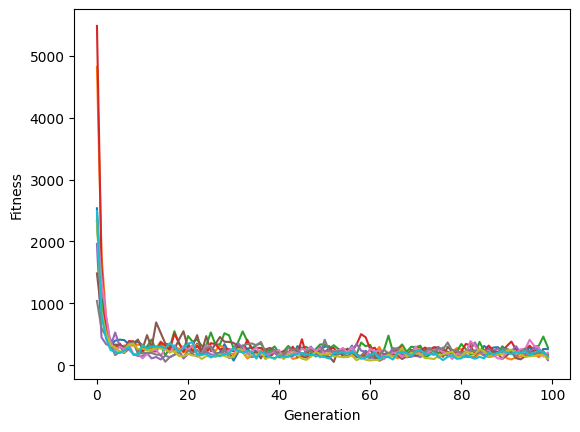

In [38]:
plt.figure()
for i in range(len(fitness_records)):
    plt.plot(fitness_records[i])
plt.xlabel("Generation")
plt.ylabel("Fitness")
# plt.plot(fitness_record)

In [12]:
pdes[pdes["flatten"]<0.8]
# view(last_atom_list[1])

,CN1,CN2,CN3,CN4,diameter_longest,diameter_pca,diameter_xy,MIAD,surface ratio,atom_number,Departure from sphere,flatten
48,5.37,2.00,3.42,1.32,10.63,11.69,9.41,4.74,1.00,19,0.211888,0.65
99,6.82,2.53,7.12,2.65,10.67,13.62,10.60,5.27,0.94,34,0.110374,0.74


In [29]:
def convex_particle(genome,lc,max_num_atoms):
    indices=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    hull=ConvexHull(particle)
    for points in lattice_big:
        if is_point_in_hull(points,hull,lc):
            indices.extend(np.where(np.all(np.isclose(points,lattice_big,rtol=1e-1),axis=1))[0])
    print(len(indices))
    print(len(particle))
    genome_recon=np.zeros(len(lattice_big))
    for i in indices:
        genome_recon[i]=1
    return genome_recon
def is_point_in_hull(point,hull,lc):
    equations=hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=lc/(2*np.sqrt(2)))

In [30]:
import plotly.graph_objs as go
from plotly.offline import plot
g_reco=convex_particle(population[35],3.77,200)
points_add,lattice=recon_coordfromcodes(g_reco,3.77,200)
points,lattice=recon_coordfromcodes(population[35],3.77,200)
# Sample 3D points
 # 30 random points in 3D

# Compute the convex hull
hull = ConvexHull(points)

# Create a Plotly figure
fig = go.Figure()

# Add points to the plot
fig.add_trace(go.Scatter3d(
    x=points_add[:, 0], y=points_add[:, 1], z=points_add[:, 2],
    mode='markers',
    marker=dict(size=5, color='blue'),
    name='Points'
))

# Add the convex hull
for simplex in hull.simplices:
    simplex = np.append(simplex, simplex[0])  # cycle back to the first vertex
    fig.add_trace(go.Scatter3d(
        x=points[simplex, 0], y=points[simplex, 1], z=points[simplex, 2],
        mode='lines',
        line=dict(color='red', width=2),
        name='Convex Hull'
    ))

# Add the faces of the convex hull
faces = hull.simplices
for face in faces:
    x = [points[vertex, 0] for vertex in face]
    y = [points[vertex, 1] for vertex in face]
    z = [points[vertex, 2] for vertex in face]
    x.append(points[face[0], 0])
    y.append(points[face[0], 1])
    z.append(points[face[0], 2])
    fig.add_trace(go.Mesh3d(
        x=x, y=y, z=z,
        opacity=0.5,
        color='cyan',
        name='Convex Hull Face'
    ))

# Set plot title and labels
fig.update_layout(
    title='3D Convex Hull',
    scene=dict(
        xaxis_title='X Axis',
        yaxis_title='Y Axis',
        zaxis_title='Z Axis'
    )
)

# Show the plot
plot(fig)

50
50


'temp-plot.html'

In [9]:
particle,lattice=recon_coordfromcodes(population[1],3.77,200)
atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
view(atom)

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

In [15]:
g_reco=convex_particle(population[35],3.77,200)
particle,lattice=recon_coordfromcodes(g_reco,3.77,200)
atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
view(atom)

50
50


<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

# more test

In [67]:
#gauss
#making lattice

def empty_lattice(lc,n1,n2,n3):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    mid_position=np.mean(lattice,axis=0)
    # lattice=np.round(lattice-mid_position,6)
    closest_index=np.where(np.all(np.isclose(mid_position,lattice,rtol=lc/(2*np.sqrt(2))),axis=1))[0][0]
    lattice=lattice-lattice[closest_index]
    return order_pos(lattice)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

def particles_encode_gen_no_oblate(lc,lattice_big,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    # transfer points to the big lattice
    indices=[]
    # genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice_big[i],rtol=1e-3),axis=1))[0])

    return lattice_big[indices]
# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,lattice_big,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        # assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    # min_num_points=num_atoms
    
    # print(f"length={np.mean(lattice_big,axis=0)}")
    # times=random.randint(1,3)
    # the extreme case is that the particle has only one layer of unit cells, which has the dimension: np.sqrt(n_max**3)*np.sqrt(n_max**3)*1
    n1=random.randint(1,np.floor(np.sqrt(n_max**3)))
    n2=n1
    n3=random.randint(1,n1)
    lattice=empty_lattice(lc,n1,n2,n3)
    num_points=len(lattice)
    #this is too strong
    while num_points<num_atoms*2 or n1*n2*n3>n_max**3:
        n1=random.randint(1,np.floor(np.sqrt(n_max**3)))
        n2=n1
        n3=random.randint(1,n1)
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
        # print((num_points,n1,n2,n3,num_atoms))
    # print(f"length={np.mean(lattice,axis=0)}")
    # transfer points to the big lattice
    indices=[]
    # genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    return lattice_big[indices]


def ini_population(lc,population_size,lattice_big,num_atoms=None,max_num_atoms=None):
    generations=[]
    n=0
    while n<population_size:
        particle=particles_encode_gen(lc,lattice_big=lattice_big,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        generations.append(particle)
        n+=1
    return generations

def fitness(particle,descriptors:dict):
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    #np.sum((true_dis-pred_dis)**2)
    sim=np.max(np.abs(pred_dis/true_dis-1))
    return sim,pred_dis

            
def parents(population,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            return list(population[i])
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return p#(p-np.min(p))/(np.max(p)-np.min(p))

def atom_cut_up_down_center(particle,theta,phi,lc):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(particle)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    closest_index=np.where(np.all(np.isclose(center,particle,rtol=lc/(1.8*np.sqrt(2))),axis=1))[0][0]
    particle_shift=particle-particle[closest_index]
    center=np.mean(particle_shift,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle_shift:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=-lc/np.sqrt(2):
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=lc/np.sqrt(2):
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    return np.array(trancate_up_particle),np.array(trancate_down_particle)


def atom_trancate_center(particle,theta,phi):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    
    # print(f"1={len(genome_recon)}")
    # print(len(particle),len(trancate_particle),len(np.where(np.array(genome_recon)==1)[0]))
    return trancate_particle
    
def atom_trancate_arbi(particle,theta,phi):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(particle)
    particle=np.array(particle)
    center_get=np.mean(particle,axis=0)
    particle_vote=particle.copy()
    if [center_get] not in particle_vote:
        np.vstack((particle_vote,center_get))
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:
    center=random.choice(particle_vote)
    # else:
    #     return particle
    ## points with coordination numbers are 12 are considered as the center of planes for truncation.
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    # if len(trancate_particle)<5:
    #     trancate_particle=[]
    #     for pos in particle:
    #         if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
    #             trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    return trancate_particle


def crossover(lc,parent1,parent2,cross_over_rate=0.6):
    def remove_duplicates(particle,lc):
        duplicates=[]
        index_get=[]
        for i in range(len(particle)):
            index=np.where(np.isclose(cdist([particle[i]],particle)[0],0,atol=1e-2))[0]
            if len(index)>1:
                duplicates.extend(index[1:])
            if index[0] not in duplicates:
                index_get.append(index[0])
        return np.array([particle[i] for i in index_get])
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,lc)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,lc)
        parent1=np.vstack((parent1_up,parent2_down))
        parent2=np.vstack((parent1_down,parent2_up))
        parent1=remove_duplicates(parent1,lc)
        parent2=remove_duplicates(parent2,lc)
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        return parent1,parent2
    else:
        return parent1,parent2
    

def mutation(particle,lc,lattice_big,max_num_atoms,mutation_rate=0.3):
    mr=random.uniform(0,1)
    num_atoms=len(particle)

    if mr<=mutation_rate/3:
        renum=0
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        particle_update=atom_trancate_center(particle,theta,phi)
        while len(particle_update)<5 and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            particle_update=atom_trancate_center(particle,theta,phi)
            renum+=1
    elif mr>mutation_rate/3 and mr<=mutation_rate*2/3:
        particle_update=particle
        renum=0
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        particle_update=atom_trancate_arbi(particle,theta,phi)
        while len(particle_update)<5 and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            particle_update=atom_trancate_arbi(particle,theta,phi)
            renum+=1
    elif mr>mutation_rate*2/3 and mr<=mutation_rate:
        #2. initialization of populations
        particle_update = ini_population(lc=lc,
                                    population_size=1,
                                    lattice_big=lattice_big,
                                    max_num_atoms=max_num_atoms,
                                    num_atoms=None)[0]
        
    else:
        particle_update=particle
    return particle_update
def convex_particle(particle,lattice_big,lc):
    indices=[]
    try:
        hull=ConvexHull(particle)
    except QhullError:
        # print("less than 3 dimensions")
        # print(particle)
        return particle
    for points in lattice_big:
        if is_point_in_hull(points,hull,lc):
            indices.extend(np.where(np.all(np.isclose(points,lattice_big,rtol=1e-1),axis=1))[0])
    # print(len(indices))
    # print(len(particle))
    return np.array([lattice_big[i] for i in indices])

def is_point_in_hull(point,hull,lc):
    equations=hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=lc/(2*np.sqrt(2)))

       

def genetic_algorithm(max_num_atoms=200,
                      generations=40,
                      population_size=100,
                      lc=3.77,
                      mutation_rate=0.3,
                      cross_over_rate=0.3,
                      elite_fraction=0.1,
                      descriptors={
                                    "flattening_moment": 1,
                                    "atom_number":143
                      }
                # "CN1":6,
                # "CN2":1.5,
                # "CN3":2,
                # "CN4":5

    ):
    #1. set up parameters

    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,int(np.sqrt(n_max**3)),int(np.sqrt(n_max**3)),int(np.sqrt(n_max**3)))

    #2. initialization of populations
    populations= ini_population(lc=lc,
                                population_size=population_size,
                                lattice_big=lattice_big,
                                num_atoms=None,max_num_atoms=max_num_atoms)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    indices_elitism=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(particle,descriptors)[0] for particle in populations]
    

    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
        #elitism
        rank=ranking_fitness(fitness_values)
        rank_sort=np.sort(rank)
        for i in range(len(rank_sort)):
            indices_elitism.extend(np.where(rank==rank_sort[i])[0])
        indices_elitism=indices_elitism[:int(elite_fraction*population_size)]
        elitism_population=[populations[i] for i in indices_elitism]
        populations_res=[populations[i] for i in range(len(populations)) if i not in indices_elitism]
        fitness_values_res=[fitness_values[i] for i in range(len(fitness_values)) if i not in indices_elitism]
    
       
        #check duplicates, if duplicates exist, then generate a new structure
        while len(new_populations)!=population_size-len(elitism_population):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))

            parent1=parents(populations_res,fitness_values_res)
            parent2=parents(populations_res,fitness_values_res)
            parent1=np.array(parent1)
            parent2=np.array(parent2)
            # fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            # fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            #[2]. crossover and mutation to generate offsprings
            children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate)
            
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1=mutation(children1,lc,lattice_big,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,lattice_big,max_num_atoms,mutation_rate=mutation_rate)
            #convex hull
            children1=convex_particle(children1,lattice_big,lc)
            children2=convex_particle(children2,lattice_big,lc)
            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1,children2])
        # while len(new_populations)>len(populations_res):
        #     new_populations.pop()
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        new_populations=elitism_population+new_populations
        #(1). elitism
        print((len(new_populations),population_size,len(populations_res)))
        assert len(new_populations)==population_size,"The population size is not correct!"
        print(len(new_populations))
        fitness_values=[]
        predict_values=[]
        for particle in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(particle,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        best_fitness=min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        std_fitness=np.std(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        best_index=fitness_values.index(best_fitness)
        #[2]. reconstruct the best solution from codes using new_populations.
        particle=new_populations[best_index]
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(ave_fitness)                         #dong
        #[4]. print output
        print(f"Generation{generation}:ave Finess={ave_fitness}+-{np.round(std_fitness,3)},best Predict={best_predict}")
        #[5]. update populations
        populations=new_populations
        #[6]. early stopping
        # if generation>10:
        #     error=fitness_record[generation-1]-fitness_record[generation]
        #     if error<1e-4:
        #         break
    #4. record the best solution
    best_index=fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    best_atom=Atoms(positions=best_solution,symbols=['Pt']*len(best_solution))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        last_atom_list.append(Atoms(positions=last_population[i],symbols=['Pt']*len(last_population[i])))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        ini_atom_list.append(Atoms(positions=ini_population_record[i],symbols=['Pt']*len(ini_population_record[i])))
    return best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population
# def genome(num_atoms):
#     np.random

In [72]:
best_atoms=[]
fitness_records=[]
fitness_values=[]
best_particles=[]
last_atom_lists=[]
for i in range(1):
    # best_atom=None
    # fitness_record=None
    # fitness_value=None
    # best_particle=None
    # last_atom_list=None
    # ini_atom_list=None
    best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population=genetic_algorithm(max_num_atoms=200,
                      generations=30,
                      population_size=400,
                      lc=3.77,
                      mutation_rate=0.3,
                      cross_over_rate=0.3,
                      descriptors={
                            "CN1":8.47,
                            "CN2":3.11,
                            "CN3":11.29,
                            "CN4":5.22
                          #'CN1':7.85,#8.47	3.11	11.29	5.22 O5OCT	
                          #'CN2':3.27,
                          #'CN3':9.60,
                          #'CN4':4.15
                                  #  "surface ratio": 0.86,
                                  #  "atom_number":44
                      })
    # best_atoms.append(best_atom)
    # fitness_records.append(fitness_record)
    # fitness_values.append(fitness_value)
    # best_particles.append(best_particle)
    # last_atom_lists.append(last_atom_list)
# best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'CN1': 8.47, 'CN2': 3.11, 'CN3': 11.29, 'CN4': 5.22}


  0%|          | 0/30 [00:00<?, ?it/s]

(400, 400, 373)
400
Generation0:ave Finess=0.25006532287211053+-0.115,best Predict=[ 8.48  3.22 11.62  5.03]
(400, 400, 373)
400
Generation1:ave Finess=0.246929255689792+-0.125,best Predict=[ 8.48  3.22 11.62  5.03]
(400, 400, 373)
400
Generation2:ave Finess=0.2530828804817666+-0.131,best Predict=[ 8.51  3.19 11.54  5.01]
(400, 400, 373)
400
Generation3:ave Finess=0.23599057748145974+-0.134,best Predict=[ 8.51  3.19 11.54  5.01]
(400, 400, 373)
400
Generation4:ave Finess=0.2269233802352695+-0.143,best Predict=[ 8.51  3.19 11.54  5.01]
(400, 400, 373)
400
Generation5:ave Finess=0.22001413851362728+-0.134,best Predict=[ 8.51  3.19 11.54  5.01]
(400, 400, 373)
400
Generation6:ave Finess=0.22394304759128125+-0.145,best Predict=[ 8.33  3.22 10.94  4.92]
(400, 400, 373)
400
Generation7:ave Finess=0.20463699619352732+-0.127,best Predict=[ 8.41  3.22 11.44  5.2 ]
(400, 400, 373)
400
Generation8:ave Finess=0.20672690452371878+-0.135,best Predict=[ 8.51  3.19 11.54  5.01]
(400, 400, 373)
400
Gen

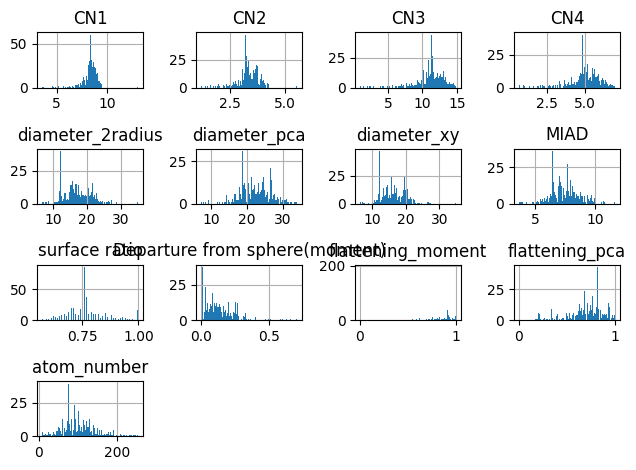

In [73]:
particles_descriptors=[]
bas=[]

for i in range(len(last_atom_list)):
    particles_descriptors.append(descriptor_table(last_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

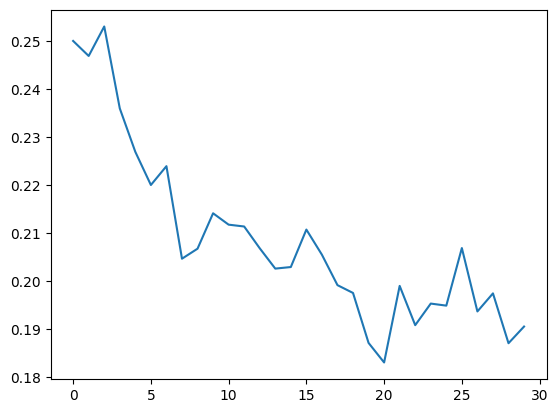

In [74]:
plt.figure()
plt.plot(fitness_record)

In [75]:
view(last_atom_list[238],viewer='x3d')

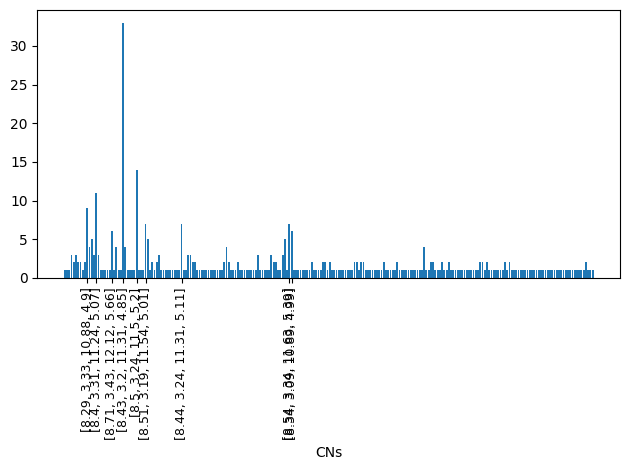

In [76]:
list_par=[]
for i in range(pdes.shape[0]):
    list_par.append([pdes.iloc[i]["CN1"],pdes.iloc[i]["CN2"],pdes.iloc[i]["CN3"],pdes.iloc[i]["CN4"]])

par_dict={}
list_read=[]
for i in range(pdes.shape[0]):
    indices=np.where(np.isclose(list_par[i],list_par,rtol=1e-2).all(axis=1))[0]
    # print(indices)
    
    # print(list_read)
    if i not in list_read:
        list_read.extend(indices)
        par_dict[f"{list_par[i]}"]={"indices":indices,"num":len(indices)}


par_dict=pd.DataFrame(par_dict)
# print(par_dict)
i=0
index_get=[]
values=[]
for k,v in par_dict.items():
    if v['num']>5:
        values.append(k)
        index_get.append(i)
    i+=1

plt.figure()
plt.bar(np.arange(par_dict.shape[1]),par_dict.loc["num"])
plt.xlabel("CNs")
plt.xticks(index_get,values,rotation=90,fontsize=9)  
plt.tight_layout()

In [78]:
par_dict["[8.43, 3.2, 11.31, 4.85]"]

indices    [40, 48, 50, 61, 65, 76, 83, 99, 156, 159, 164...
num                                                       33
Name: [8.43, 3.2, 11.31, 4.85], dtype: object

In [79]:
view(last_atom_list[40],viewer='x3d')

# 1. initialization


In [239]:
max_num_atoms=200
generations=5
population_size=100
lc=3.77
mutation_rate=0.3
cross_over_rate=0.3
descriptors={
            "flattening_moment": 1,
            "atom_number":55
}
num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
n_max=int(np.ceil(np.cbrt(num_lattice)))
lattice_big=empty_lattice(lc,int(np.sqrt(n_max**3)),int(np.sqrt(n_max**3)),int(np.sqrt(n_max**3)))

#2. initialization of populations
populations= ini_population(lc=lc,
                            population_size=population_size,
                            lattice_big=lattice_big,
                            num_atoms=None,max_num_atoms=max_num_atoms)

In [240]:
# single particle
# populations= ini_population(lc=lc,
#                             population_size=1,
#                             lattice_big=lattice_big,
#                             num_atoms=None,max_num_atoms=max_num_atoms)
# populations[0]

In [241]:
fitness_record=[]
best_particle=[]
#3. calculate fitness for populations
fitness_values=[fitness(particle,descriptors)[0] for particle in populations]
#4. start iteration


# 2. crossover

In [242]:
generation=1
# clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
#(1). generate new populations
new_populations = []

#check duplicates, if duplicates exist, then generate a new structure

parent1=parents(populations,fitness_values)
parent2=parents(populations,fitness_values)
parent1=np.array(parent1)
parent2=np.array(parent2)
if random.random()<cross_over_rate:
    theta=random.uniform(0,np.pi)
    phi=random.uniform(0,2*np.pi)
    # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
    # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
    parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,lc)
    parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,lc)
    parent1=np.vstack((parent1_up,parent2_down))
    parent2=np.vstack((parent1_down,parent2_up))
children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate)
# [np.where(np.isclose(cdist([parent1[i]],parent1)[0],0,atol=1e-2))[0] for i in range(len(parent1))]


print(children1,children2)
# cdist([parent1[3]],parent1)

[[-3.77   0.     0.   ]
 [-1.885 -1.885  0.   ]
 [-1.885  0.    -1.885]
 [ 0.     0.     0.   ]
 [-1.885  1.885  0.   ]
 [-1.885  0.     1.885]
 [-3.77  -1.885 -1.885]
 [-3.77  -1.885  1.885]
 [-3.77   1.885 -1.885]
 [-3.77   1.885  1.885]
 [ 0.    -1.885 -1.885]
 [ 0.    -1.885  1.885]
 [ 0.     1.885 -1.885]
 [ 0.     1.885  1.885]
 [-3.77   0.    -3.77 ]
 [-5.655  0.    -1.885]
 [-5.655  1.885  0.   ]
 [-5.655  0.     1.885]
 [-3.77   0.     3.77 ]
 [-3.77   3.77   0.   ]
 [-1.885 -1.885 -3.77 ]
 [-1.885 -3.77  -1.885]
 [ 0.    -3.77   0.   ]
 [-1.885 -1.885  3.77 ]
 [ 0.     0.    -3.77 ]
 [-1.885  1.885 -3.77 ]
 [ 0.     0.     3.77 ]
 [-1.885  1.885  3.77 ]
 [-1.885  3.77  -1.885]
 [ 0.     3.77   0.   ]
 [ 0.     0.     0.   ]
 [ 0.     0.     3.77 ]
 [ 0.    -1.885  1.885]
 [-1.885  0.     1.885]
 [ 0.     1.885  1.885]
 [ 1.885  0.     1.885]
 [-1.885 -1.885  0.   ]
 [-1.885 -1.885  3.77 ]
 [-1.885  1.885  0.   ]
 [-1.885  1.885  3.77 ]
 [ 1.885 -1.885  0.   ]
 [ 1.885 -1.885 

# 3. convex hull

In [249]:
def convex_particle(particle,lattice_big,lc):
    indices=[]
    try:
        hull=ConvexHull(particle)
    except QhullError:
        print("less than 3 dimensions")
        print(particle)
        return particle
    for points in lattice_big:
        if is_point_in_hull(points,hull,lc):
            indices.extend(np.where(np.all(np.isclose(points,lattice_big,rtol=1e-1),axis=1))[0])
    # print(len(indices))
    # print(len(particle))
    return np.array([lattice_big[i] for i in indices])
def is_point_in_hull(point,hull,lc):
    equations=hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=lc/(2*np.sqrt(2)))



children1=convex_particle(children1,lattice_big,lc)
children2=convex_particle(children2,lattice_big,lc)
# print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
children1=mutation(children1,lc,lattice_big,max_num_atoms,mutation_rate=1)
children2=mutation(children2,lc,lattice_big,max_num_atoms,mutation_rate=1)

<Popen: returncode: None args: ['c:\\Users\\kaife\\Anaconda3\\envs\\NN_work\...>

# 4. mutation

In [278]:
children1=mutation(children1,lc,lattice_big,max_num_atoms,mutation_rate=mutation_rate)
children2=mutation(children2,lc,lattice_big,max_num_atoms,mutation_rate=mutation_rate)

view(Atoms(positions=convex_particle(children2,lattice_big,lc),symbols=['Pt']*len(convex_particle(children2,lattice_big,lc))))
children2

array([[ 7.54 ,  9.425, -1.885],
       [ 9.425,  7.54 , -1.885],
       [ 9.425,  9.425, -3.77 ],
       [11.31 ,  9.425, -1.885],
       [ 9.425, 11.31 , -1.885],
       [ 9.425,  9.425,  0.   ],
       [ 7.54 ,  7.54 , -3.77 ],
       [ 7.54 ,  7.54 ,  0.   ],
       [ 7.54 , 11.31 , -3.77 ],
       [ 7.54 , 11.31 ,  0.   ],
       [11.31 ,  7.54 , -3.77 ],
       [11.31 ,  7.54 ,  0.   ],
       [11.31 , 11.31 , -3.77 ],
       [11.31 , 11.31 ,  0.   ],
       [ 7.54 ,  5.655, -1.885],
       [ 5.655,  7.54 , -1.885],
       [ 5.655,  9.425, -3.77 ],
       [ 5.655, 11.31 , -1.885],
       [ 5.655,  9.425,  0.   ],
       [ 7.54 , 13.195, -1.885],
       [ 9.425,  5.655, -3.77 ],
       [11.31 ,  5.655, -1.885],
       [ 9.425,  5.655,  0.   ],
       [ 9.425, 13.195, -3.77 ],
       [11.31 , 13.195, -1.885],
       [ 9.425, 13.195,  0.   ],
       [13.195,  7.54 , -1.885],
       [13.195,  9.425, -3.77 ],
       [13.195, 11.31 , -1.885],
       [13.195,  9.425,  0.   ],
       [ 3

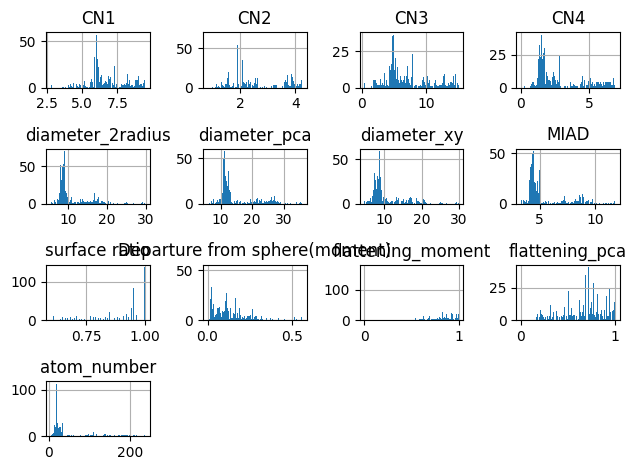

In [294]:
particles=[]
atoms=[]
for i in range(500):
    children=mutation(parent1,lc,lattice_big,max_num_atoms,mutation_rate=1)
    children=convex_particle(children,lattice_big,lc)
    particles.append(children)
for i in range(len(particles)):
    atoms.append(Atoms(positions=particles[i],symbols=['Pt']*len(particles[i])))

particles_descriptors=[]
bas=[]

for i in range(len(atoms)):
    particles_descriptors.append(descriptor_table(atoms[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [57]:
from shape_proj_util.geo_tools.convenient_datasoup import *
data=particle_database(element='Pt')
data.predefine_data(3.77)
data.shape_info().T

,CN1,CN2,CN3,CN4,diameter_2radius,diameter_pca,diameter_xy,MIAD,surface ratio,Departure from sphere(moment),flattening_moment,flattening_pca,atom_number
OCT_2,4.00,1.00,0.00,0.00,3.77,6.53,3.77,2.89,1.00,0.000000,1.00,1.00,6.0
OCT_3,6.32,1.89,5.05,1.89,7.54,13.06,7.54,4.16,0.95,0.000000,0.00,1.00,19.0
OCT_4,7.64,2.59,8.73,3.82,11.31,18.24,11.31,5.49,0.86,0.000000,1.00,1.00,44.0
OCT_5,8.47,3.11,11.29,5.22,15.08,25.96,15.08,6.84,0.78,0.000000,0.00,1.00,85.0
OCT_6,9.04,3.49,13.15,6.25,18.85,29.81,18.85,8.19,0.70,0.000000,1.00,1.00,146.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
HEX_O1_2_SQ_O2_cut_ori_100_l_2,8.44,4.66,3.21,2.86,13.81,20.30,13.59,7.03,0.73,0.050589,0.77,0.57,91.0
HEX_O1_2_SQ_O2_cut_ori_100_l_3,7.89,4.11,3.06,2.57,14.26,19.68,13.59,6.70,0.81,0.109811,0.68,0.42,70.0
HEX_O1_2_SQ_O2_cut_ori_100_l_4,7.13,2.96,2.74,5.13,12.24,15.55,11.92,6.05,0.91,0.172209,0.61,0.35,46.0
HEX_O1_2_SQ_O2_cut_ori_100_l_5,5.76,2.88,2.08,3.84,11.39,11.47,11.31,5.30,1.00,0.244533,0.56,0.24,25.0


In [58]:
view(data.shape_all[3].atom_obj,viewer='x3d')